In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize
from scipy import signal
from mpl_toolkits.axes_grid1 import ImageGrid
import datetime

Some basic functions

In [3]:
def cal_arround(origin, i, j, size):
    row = np.shape(origin)[0]
    col = np.shape(origin)[1]
    act_row = min(row,i+size) - max(i-size,0) + 1
    act_column = min(col,j+size) - max(j-size,0) + 1
    all = act_row * act_column
    
    m = max(i-size,0);
    n = max(j-size,0);
    count = 0
    while m <= min(row-1,i+size):
        n = max(j-size,0)
        while n <= min(col-1,j+size):
            count += origin[m][n]
            n += 1
        m += 1
    return count/all

def cal_vague(origin, size):
    origin_copy = origin.copy()
    row = np.shape(origin)[0]
    col = np.shape(origin)[1]
    for i in range(row):
        for j in range(col):
            origin_copy[i][j] = cal_arround(origin, i, j, size)
    return origin_copy

#consider another case, the Gaussian blob is not central symmetric, we need to add two extra parameters. 
def GaussianGeneration(params,row,col):
    length=np.shape(params)[0]
    params_num=int((length-1)/4)
    gaussian_frame=np.zeros([row,col])
    background=params[-1]
    for m in range(params_num):
        x_pos=params[m*4]
        y_pos=params[m*4+1]
        sigma=params[m*4+2]
        peak=params[m*4+3]
        for i in range(row):
            for j in range(col):               
                gaussian_frame[i,j]+=peak*np.exp(-((i-x_pos)**2+(j-y_pos)**2)/(2*sigma**2))
    gaussian_frame=gaussian_frame+background
    return gaussian_frame

def GaussianFitting(original_image,params):
    x_=np.arange(original_image.shape[0])
    y_=np.arange(original_image.shape[1])
    X,Y=np.meshgrid(x_,y_)
    def residuals(fitting_params,x,y):
        gaussian_image=GaussianGeneration(fitting_params,original_image.shape[0],original_image.shape[1])
        return gaussian_image[x,y]-original_image[x,y]
    fit_result=optimize.leastsq(residuals,params,args=(X.flatten(),Y.flatten()))[0]
    return fit_result

#you need to consider the background value.
def LocalGaussianFitting(point,image,length):
    col,row=image.shape
    
    x_min=np.max([0,point[0]-length])
    x_max=np.min([col-1,point[0]+length])
    x_=np.arange(x_min,x_max,1)
    
    y_min=np.max([0,point[1]-length])
    y_max=np.min([row-1,point[1]+length])
    y_=np.arange(y_min,y_max,1)
    
    X,Y=np.meshgrid(x_,y_)

    copy_image = image.copy()
    copy_image = cal_vague(copy_image, 5)
    m1 = max(point[0]-length, 0);
    n1 = max(point[1]-length, 0);
    m2 = min(row-1, point[0]+length)
    n2 = min(col-1, point[1]+length)
    index = np.unravel_index(copy_image.argmax(), copy_image.shape)
    peak = image[index[0],index[1]]
    
    '''
    index = np.unravel_index(copy_noised_image.argmax(), copy_noised_image.shape)
    peak = image[index[0],index[1]]
    '''

    def residuals(p,x,y):
        sigma, background = p
        return image[x,y]-((peak-background)*np.exp(-((x-point[0])**2+(y-point[1])**2)/(2*sigma**2))+background)
    result = optimize.leastsq(residuals,[5,0.05], args=(X.flatten(),Y.flatten()))[0]
    return result

def GaussianDeduction(original_image,params):
    return original_image-GaussianGeneration(params,original_image.shape[0],original_image.shape[1])

def ErrorFunction(original_image,params):
    return np.sum(GaussianDeduction(original_image,params)**2)

def ParamsAppend(original_image,params):
    params_fitted=GaussianFitting(original_image,params).tolist()
    residual_frame=GaussianDeduction(copy_noised_image,params_fitted)
    background=np.array([params_fitted[-1]])
    del params_fitted[-1]
    params_fitted=np.array(params_fitted)
    brightest_coordinates=np.unravel_index(np.argmax(residual_frame),residual_frame.shape)
    estm_sigma=abs(LocalGaussianFitting(brightest_coordinates,residual_frame,5)[0])   
    estm_peak=residual_frame[brightest_coordinates[0],brightest_coordinates[1]]
    new_params=np.array([brightest_coordinates[0],brightest_coordinates[1],estm_sigma,estm_peak])
    return np.concatenate((params_fitted,new_params,background),axis = 0)

def FitFirstPoint(original_image,sigma):
    brightest_coordinates=np.unravel_index(np.argmax(original_image),original_image.shape)
    alt=np.max(original_image)
    background=np.min(original_image)
    updated_sigma=LocalGaussianFitting(brightest_coordinates,original_image,sigma)[0]
    params=GaussianFitting(original_image,
                           [brightest_coordinates[0],brightest_coordinates[1],updated_sigma,alt,background])
    return params

def Regulation(params):
    length=len(params)
    params_num=int((length-1)/4)
    background=np.clip(params[-1],0,0.2)
    refined_params=[]
    for m in range(params_num):
        refined_params.append(np.clip(params[m*4],0,60))  #x_pos
        refined_params.append(np.clip(params[m*4+1],0,60))  #y_pos
        refined_params.append(np.clip(params[m*4+2],1,10))  #sigma
        refined_params.append(np.clip(params[m*4+3],0,1))  #altitude
    refined_params.append(background)
    refined_params=np.array(refined_params)
    return refined_params

def IterativeParamsAppend(original_image):
    params=FitFirstPoint(original_image,5)
    while ErrorFunction(original_image,params)>0.1:
        unfitted_params=params
        params=ParamsAppend(original_image,params)
        params=GaussianFitting(original_image,params)
        refined_params=Regulation(params)
        print(params)
        print(ErrorFunction(original_image,params))
        if ErrorFunction(original_image,unfitted_params)<ErrorFunction(original_image,refined_params):
            print(refined_params)
            params=refined_params
            break
        if ErrorFunction(original_image,unfitted_params)-ErrorFunction(original_image,params)<=0.02:            
            params=unfitted_params
            break
            
    return params,(ErrorFunction(original_image,params))

def FindGlobalMinimum(original_image,params,n):
    x_=np.arange(original_image.shape[0])
    y_=np.arange(original_image.shape[1])
    X,Y=np.meshgrid(x_,y_)
    def residuals(fitting_params,x,y):
        gaussian_image=GaussianGeneration(fitting_params,original_image.shape[0],original_image.shape[1])
        return gaussian_image[x,y]-original_image[x,y]
    def error_func(fitting_params,x,y):
        return np.sum(residuals(fitting_params,x,y)**2)
    fit_result=optimize.basinhopping(error_func,params,niter=n, 
                                     minimizer_kwargs={"method":"bfgs", "args":(X.flatten(),Y.flatten())})
    return np.array(fit_result.x)

def PoissonNoise(image,digit):
    row=image.shape[0]
    col=image.shape[1]
    maximum=np.max(image)
    index=int(digit/maximum)
    image_into_digits=(image*index).astype(int)
    noised_image=np.random.poisson(image_into_digits)/index
    return noised_image

def SNR(image,noised_image):
    return np.sum(image)/np.sum(abs(image-noised_image))

In [4]:
point1=np.array([1,15,2,0.3])
point2=np.array([2,30,2,0.3])
point3=np.array([3,45,2,0.3])
point3=np.array([4,45,2,0.3])
point3=np.array([5,45,2,0.3])
point3=np.array([6,45,2,0.3])
point3=np.array([7,45,2,0.3])
point3=np.array([8,45,2,0.3])
background=np.array([0.05])
params=np.concatenate((point1,point2,point3,background),axis = 0)
params1=np.concatenate((point1,background),axis = 0)
params2=np.concatenate((point2,background),axis = 0)
params3=np.concatenate((point3,background),axis = 0)
params

array([15.  , 15.  ,  2.  ,  0.3 , 30.  , 30.  ,  2.  ,  0.3 , 45.  ,
       45.  ,  2.  ,  0.3 ,  0.05])

Generating noised image to simulate ions' images

Text(0.5, 1.0, 'noised image')

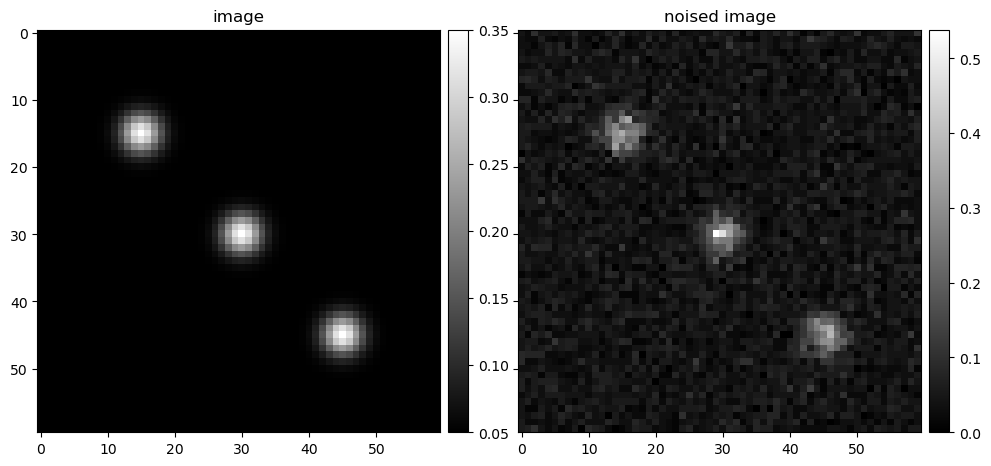

In [5]:
image=GaussianGeneration(params,60,60)
noised_image=PoissonNoise(image,32)
fig = plt.figure(1,figsize=(40,40))
grid = ImageGrid(fig, 236, 
                nrows_ncols=(1,2),
                axes_pad=0.5,
                share_all=False,
                cbar_location ="right",
                cbar_mode="each",
                cbar_size="5%",
                cbar_pad="2%")
im=grid[0].imshow(image,cmap='gray')
grid.cbar_axes[0].colorbar(im)
im=grid[1].imshow(noised_image,cmap='gray')
grid.cbar_axes[1].colorbar(im)
grid[0].set_title("image")
grid[1].set_title("noised image")

In [6]:
copy_noised_image = noised_image.copy()
copy_noised_image = cal_vague(noised_image, 5)

print(ErrorFunction(noised_image,params))

# print(SNR(image,noised_image))

2.1595824971027993


In [7]:
pa=IterativeParamsAppend(noised_image)[0]
print(pa)

start=datetime.datetime.now()
fgm=FindGlobalMinimum(noised_image,params,5)
end=datetime.datetime.now()
print(end-start)
print(fgm)

[ 3.00133121e+01  2.99461287e+01  1.70784710e+00  3.54556775e-01
  8.65694389e+03  8.45582759e+03 -1.67166007e+05 -2.30573365e+01
  2.30456237e+01]
4.165752774077518
[30.01331212 29.94612874  1.7078471   0.35455677 60.         60.
  1.          0.          0.2       ]
[30.01331212 29.94612874  1.7078471   0.35455677 60.         60.
  1.          0.          0.2       ]
0:00:21.050233
[1.50060315e+01 1.51129684e+01 2.08193391e+00 2.89891603e-01
 3.00170772e+01 2.99463549e+01 1.75814354e+00 3.53071570e-01
 4.49401715e+01 4.53563198e+01 2.02730474e+00 2.93670534e-01
 4.38077934e-02]


In [8]:
print(ErrorFunction(noised_image,pa))
print(ErrorFunction(noised_image,params))
print(ErrorFunction(noised_image,fgm))

87.11357023094563
2.1595824971027993
1.9760927925247043


Fitting images and regenerate the images based on the simulation

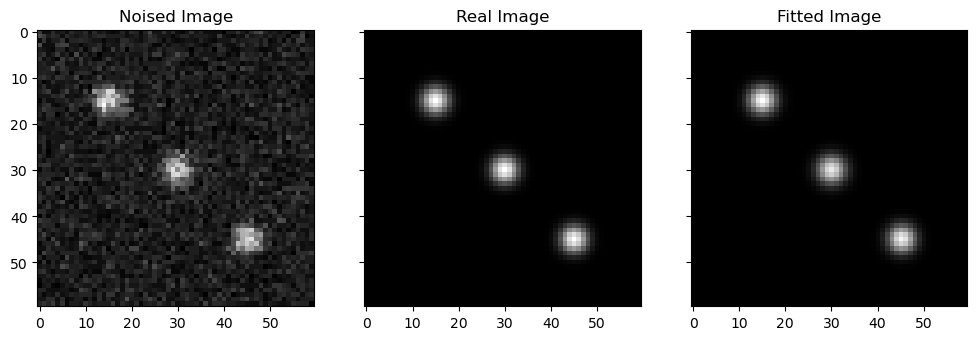

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid
from scipy import optimize

# Assuming the params array is already defined and available in the scope

def GaussianGeneration(params, row, col):
    length = np.shape(params)[0]
    params_num = int((length - 1) // 4)
    gaussian_frame = np.zeros([row, col])
    background = params[-1]
    for m in range(params_num):
        x_pos = params[m * 4]
        y_pos = params[m * 4 + 1]
        sigma = params[m * 4 + 2]
        peak = params[m * 4 + 3]
        for i in range(row):
            for j in range(col):
                gaussian_frame[i, j] += peak * np.exp(-((i - x_pos)**2 + (j - y_pos)**2) / (2 * sigma**2))
    gaussian_frame += background
    return gaussian_frame

# Generate an image with Gaussian blobs (parameters need to be defined for your specific case)
image = GaussianGeneration(params, 60, 60)

# Function to add Poisson noise to the image
def PoissonNoise(image, digit):
    maximum = np.max(image)
    index = int(digit / maximum)
    image_into_digits = (image * index).astype(int)
    noised_image = np.random.poisson(image_into_digits) / index
    return noised_image

# Add noise to the generated image
noised_image = PoissonNoise(image, 32)

# Function to fit the Gaussians to the noisy image
def FindGlobalMinimum(original_image, params, n):
    x_ = np.arange(original_image.shape[0])
    y_ = np.arange(original_image.shape[1])
    X, Y = np.meshgrid(x_, y_)
    
    def residuals(fitting_params, x, y):
        gaussian_image = GaussianGeneration(fitting_params, original_image.shape[0], original_image.shape[1])
        return gaussian_image[x, y] - original_image[x, y]

    def error_func(fitting_params, x, y):
        return np.sum(residuals(fitting_params, x, y)**2)

    fit_result = optimize.basinhopping(error_func, params, niter=n, 
                                      minimizer_kwargs={"method": "bfgs", "args": (X.flatten(), Y.flatten())})
    return np.array(fit_result.x)

# Perform fitting to find the fitted parameters
fitted_params = FindGlobalMinimum(noised_image, params, 5)

# Generate the fitted image using the fitted parameters
fitted_image = GaussianGeneration(fitted_params, 60, 60)

# Plot the noised, original, and fitted images
fig = plt.figure(figsize=(12, 4))
grid = ImageGrid(fig, 111, nrows_ncols=(1, 3), axes_pad=0.5)

# Noised image
im0 = grid[0].imshow(noised_image, cmap='gray')
grid[0].set_title("Noised Image")
grid.cbar_axes[0].colorbar(im0)

# Original image
im1 = grid[1].imshow(image, cmap='gray')
grid[1].set_title("Real Image")
grid.cbar_axes[1].colorbar(im1)

# Fitted image
im2 = grid[2].imshow(fitted_image, cmap='gray')
grid[2].set_title("Fitted Image")
grid.cbar_axes[2].colorbar(im2)

plt.show()

Improving the contrast of image and loading FITS files

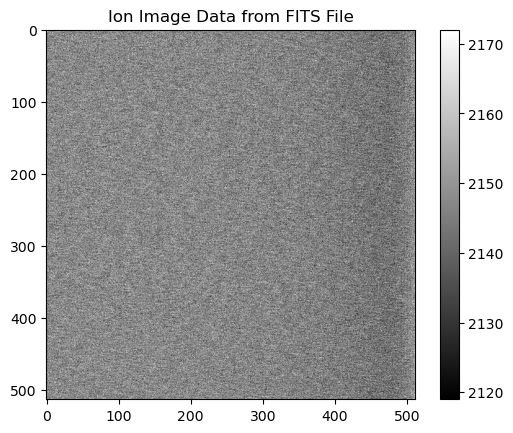

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid
from scipy import optimize
from astropy.io import fits

# Load the FITS file
path = 'D:/Google_Drive/NUVU_Data/old nc-image/'
with fits.open(path + 'nc-image_10.fits') as hdul:
    ion_image_data = hdul[0].data  # Assuming the image data is in the primary HDU

# Display the image
plt.imshow(ion_image_data, cmap='gray')
plt.colorbar()
plt.title('Ion Image Data from FITS File')
plt.show()


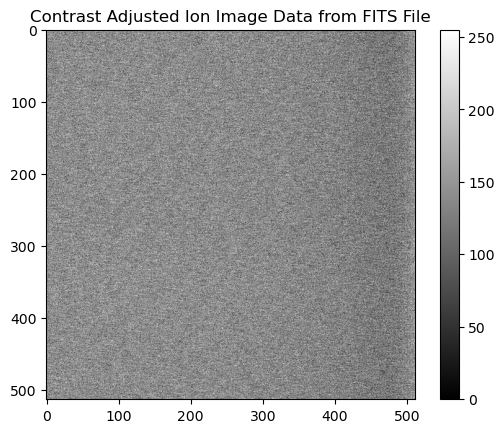

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# Load the FITS file
with fits.open(path + 'nc-image_12.fits') as hdul:
    # Assuming the image data is in the primary HDU
    ion_image_data = hdul[0].data

# Function to scale image data for contrast enhancement
def scale_image_data(image_data, scale_min=None, scale_max=None):
    """
    Scale the image data between 0 and 1 using min-max scaling.
    Optionally provide scale_min and scale_max to set custom scaling.
    """
    if scale_min is None:
        scale_min = np.min(image_data)
    if scale_max is None:
        scale_max = np.max(image_data)
    scaled_data = (image_data - scale_min) / (scale_max - scale_min)
    scaled_data[scaled_data < 0] = 0
    scaled_data[scaled_data > 1] = 1
    return (scaled_data * 255).astype(np.uint8)

# Adjust the contrast of the image by scaling its intensity
contrast_adjusted_data = scale_image_data(ion_image_data)

# Display the image with adjusted contrast
plt.imshow(contrast_adjusted_data, cmap='gray')
plt.colorbar()
plt.title('Contrast Adjusted Ion Image Data from FITS File')
plt.show()


How to convert a PNG image into a 2d numpy array

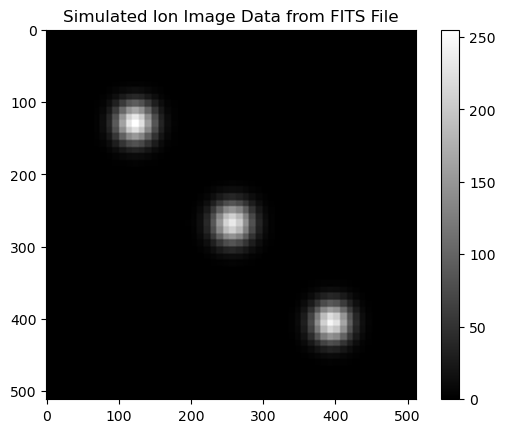

In [36]:
from PIL import Image
import numpy as np

# Open the PNG image
path = 'D:/Google_Drive/NUVU_Data/'
image_path = 'test_image.png'
with Image.open(path + image_path) as img:
    # Convert the image to grayscale
    img_gray = img.convert('L')
    # Resize the image to 512 x 512 pixels
    img_resized = img_gray.resize((512, 512))
    # Convert the image to a 2D numpy array
    ion_image_array = np.array(img_resized)

# Display the shape to confirm it's 512 x 512
ion_image_array.shape

# Display the image
plt.imshow(ion_image_array, cmap='gray')
plt.colorbar()
plt.title('Simulated Ion Image Data from FITS File')
plt.show()

Some real ion images

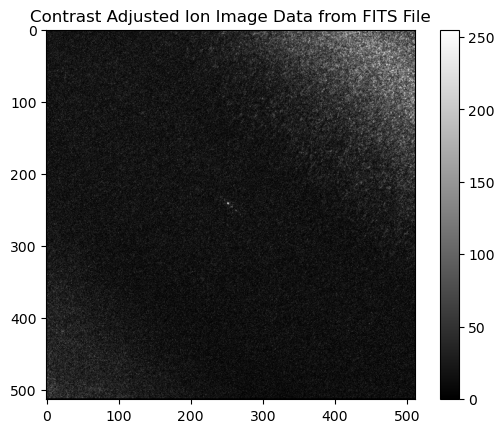

In [64]:
path = 'D:/Google_Drive/NUVU_Data/NuPixel Images/'

# Load the FITS file
with fits.open(path + 'nc-image_40.fits') as hdul:
    # Assuming the image data is in the primary HDU
    ion_image_data = hdul[0].data

# Function to scale image data for contrast enhancement
def scale_image_data(image_data, scale_min=None, scale_max=None):
    """
    Scale the image data between 0 and 1 using min-max scaling.
    Optionally provide scale_min and scale_max to set custom scaling.
    """
    if scale_min is None:
        scale_min = np.min(image_data)
    if scale_max is None:
        scale_max = np.max(image_data)
    scaled_data = (image_data - scale_min) / (scale_max - scale_min)
    scaled_data[scaled_data < 0] = 0
    scaled_data[scaled_data > 1] = 1
    return (scaled_data * 255).astype(np.uint8)

# Adjust the contrast of the image by scaling its intensity
contrast_adjusted_data = scale_image_data(ion_image_data)

# Display the image with adjusted contrast
plt.imshow(contrast_adjusted_data, cmap='gray')
plt.colorbar()
plt.title('Contrast Adjusted Ion Image Data from FITS File')
plt.show()


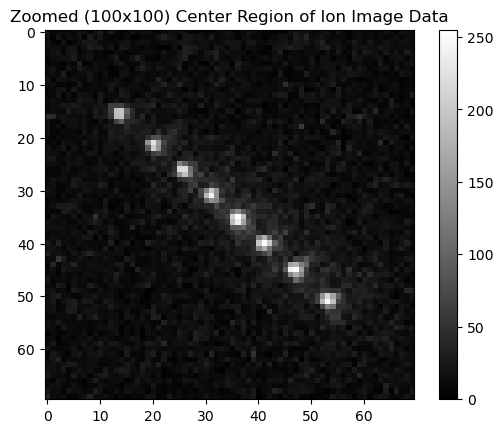

In [56]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

# Load the FITS file
fits_file_path = 'D:/Google_Drive/NUVU_Data/NuPixel Images/' + 'nc-image_38.fits'
with fits.open(fits_file_path) as hdul:
    # Assuming the image data is in the primary HDU
    ion_image_data = hdul[0].data

# Function to scale image data for contrast enhancement
def scale_image_data(image_data, scale_min=None, scale_max=None):
    """
    Scale the image data between 0 and 1 using min-max scaling.
    Optionally provide scale_min and scale_max to set custom scaling.
    """
    if scale_min is None:
        scale_min = np.min(image_data)
    if scale_max is None:
        scale_max = np.max(image_data)
    scaled_data = (image_data - scale_min) / (scale_max - scale_min)
    scaled_data[scaled_data < 0] = 0
    scaled_data[scaled_data > 1] = 1
    return (scaled_data * 255).astype(np.uint8)

# Adjust the contrast of the image by scaling its intensity
contrast_adjusted_data = scale_image_data(ion_image_data)

# Determine the center of the image
center_x, center_y = contrast_adjusted_data.shape[1] // 2, contrast_adjusted_data.shape[0] // 2

# Define the size of the zoomed region
zoom_size = 100

# Calculate the coordinates for the zoomed region
# start_x = center_x - zoom_size // 2
# end_x = center_x + zoom_size // 2
# start_y = center_y - zoom_size // 2
# end_y = center_y + zoom_size // 2
start_x = center_x - 40
end_x = center_x + 30
start_y = center_y - 50
end_y = center_y + 20

# Extract the zoomed region
zoomed_data_global = contrast_adjusted_data[start_y:end_y, start_x:end_x]

# Display the zoomed image
plt.imshow(zoomed_data_global, cmap='gray')
plt.colorbar()
plt.title('Zoomed (100x100) Center Region of Ion Image Data')
plt.show()

In [60]:
zoomed_data_global.shape[1]

70

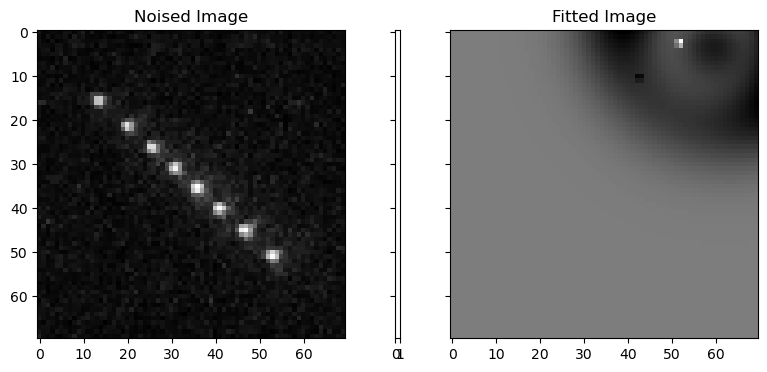

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid
from scipy import optimize

# Assuming the params array is already defined and available in the scope

def GaussianGeneration(params, row, col):
    length = np.shape(params)[0]
    params_num = int((length - 1) // 4)
    gaussian_frame = np.zeros([row, col])
    background = params[-1]
    for m in range(params_num):
        x_pos = params[m * 4]
        y_pos = params[m * 4 + 1]
        sigma = params[m * 4 + 2]
        peak = params[m * 4 + 3]
        for i in range(row):
            for j in range(col):
                gaussian_frame[i, j] += peak * np.exp(-((i - x_pos)**2 + (j - y_pos)**2) / (2 * sigma**2))
    gaussian_frame += background
    return gaussian_frame

# Function to add Poisson noise to the image
def PoissonNoise(image, digit):
    maximum = np.max(image)
    index = int(digit / maximum)
    image_into_digits = (image * index).astype(int)
    noised_image = np.random.poisson(image_into_digits) / index
    return noised_image

# Function to fit the Gaussians to the noisy image
def FindGlobalMinimum(original_image, params, n):
    x_ = np.arange(original_image.shape[0])
    y_ = np.arange(original_image.shape[1])
    X, Y = np.meshgrid(x_, y_)
    
    def residuals(fitting_params, x, y):
        gaussian_image = GaussianGeneration(fitting_params, original_image.shape[0], original_image.shape[1])
        return gaussian_image[x, y] - original_image[x, y]

    def error_func(fitting_params, x, y):
        return np.sum(residuals(fitting_params, x, y)**2)

    fit_result = optimize.basinhopping(error_func, params, niter=n, 
                                      minimizer_kwargs={"method": "bfgs", "args": (X.flatten(), Y.flatten())})
    return np.array(fit_result.x)

point1=np.array([1,15,2,0.3])
point2=np.array([2,30,2,0.3])
point3=np.array([3,45,2,0.3])
point4=np.array([4,45,2,0.3])
point5=np.array([5,45,2,0.3])
point6=np.array([6,45,2,0.3])
point7=np.array([7,45,2,0.3])
point8=np.array([8,45,2,0.3])
background=np.array([0.05])
params=np.concatenate((point1,point2,point3,point4,point5,point6,point7,point8,background),axis = 0)

# Add noise to the generated image
# noised_image = PoissonNoise(image, 32)
noised_image = zoomed_data_global

# Perform fitting to find the fitted parameters
fitted_params = FindGlobalMinimum(noised_image, params, 8)

# Generate the fitted image using the fitted parameters
fitted_image = GaussianGeneration(fitted_params, zoomed_data_global.shape[0], zoomed_data_global.shape[1])

# Plot the noised, original, and fitted images
fig = plt.figure(figsize=(12, 4))
grid = ImageGrid(fig, 111, nrows_ncols=(1, 3), axes_pad=0.5)

# Noised image
im0 = grid[0].imshow(noised_image, cmap='gray')
grid[0].set_title("Noised Image")
grid.cbar_axes[0].colorbar(im0)

# Fitted image
im2 = grid[2].imshow(fitted_image, cmap='gray')
grid[2].set_title("Fitted Image")
grid.cbar_axes[2].colorbar(im2)

plt.show()

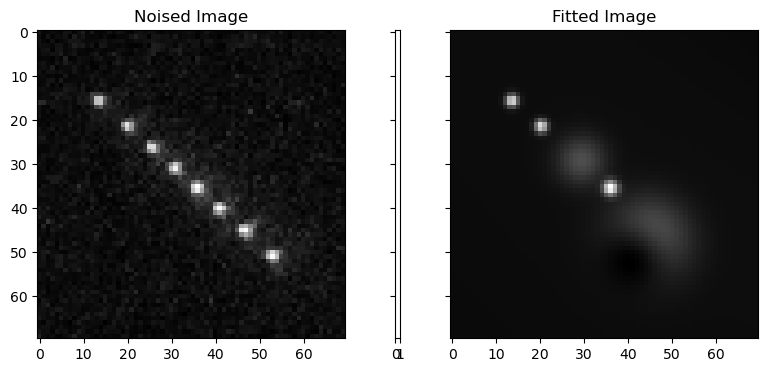

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid
from scipy import optimize

# Assuming the params array is already defined and available in the scope

def GaussianGeneration(params, row, col):
    length = np.shape(params)[0]
    params_num = int((length - 1) // 4)
    gaussian_frame = np.zeros([row, col])
    background = params[-1]
    for m in range(params_num):
        x_pos = params[m * 4]
        y_pos = params[m * 4 + 1]
        sigma = params[m * 4 + 2]
        peak = params[m * 4 + 3]
        for i in range(row):
            for j in range(col):
                gaussian_frame[i, j] += peak * np.exp(-((i - x_pos)**2 + (j - y_pos)**2) / (2 * sigma**2))
    gaussian_frame += background
    return gaussian_frame

# Function to add Poisson noise to the image
def PoissonNoise(image, digit):
    maximum = np.max(image)
    index = int(digit / maximum)
    image_into_digits = (image * index).astype(int)
    noised_image = np.random.poisson(image_into_digits) / index
    return noised_image

# Function to fit the Gaussians to the noisy image
def FindGlobalMinimum(original_image, params, n):
    x_ = np.arange(original_image.shape[0])
    y_ = np.arange(original_image.shape[1])
    X, Y = np.meshgrid(x_, y_)
    
    def residuals(fitting_params, x, y):
        gaussian_image = GaussianGeneration(fitting_params, original_image.shape[0], original_image.shape[1])
        return gaussian_image[x, y] - original_image[x, y]

    def error_func(fitting_params, x, y):
        return np.sum(residuals(fitting_params, x, y)**2)

    fit_result = optimize.basinhopping(error_func, params, niter=n, 
                                      minimizer_kwargs={"method": "bfgs", "args": (X.flatten(), Y.flatten())})
    return np.array(fit_result.x)

point1=np.array([10,5,2,0.3])
point2=np.array([15,10,2,0.3])
point3=np.array([20,15,2,0.3])
point4=np.array([25,20,2,0.3])
point5=np.array([30,25,2,0.3])
point6=np.array([35,30,2,0.3])
point7=np.array([40,35,2,0.3])
point8=np.array([45,40,2,0.3])
background=np.array([0.05])
params=np.concatenate((point1,point2,point3,point4,point5,point6,point7,point8,background),axis = 0)

# Add noise to the generated image
# noised_image = PoissonNoise(image, 32)
zoomed_data_global = contrast_adjusted_data[start_y:end_y, start_x:end_x]
noised_image = zoomed_data_global

# Perform fitting to find the fitted parameters
fitted_params = FindGlobalMinimum(noised_image, params, 8)

# Generate the fitted image using the fitted parameters
fitted_image = GaussianGeneration(fitted_params, zoomed_data_global.shape[0], zoomed_data_global.shape[1])

# Plot the noised, original, and fitted images
fig = plt.figure(figsize=(12, 4))
grid = ImageGrid(fig, 111, nrows_ncols=(1, 3), axes_pad=0.5)

# Noised image
im0 = grid[0].imshow(noised_image, cmap='gray')
grid[0].set_title("Noised Image")
grid.cbar_axes[0].colorbar(im0)

# Fitted image
im2 = grid[2].imshow(fitted_image, cmap='gray')
grid[2].set_title("Fitted Image")
grid.cbar_axes[2].colorbar(im2)

plt.show()

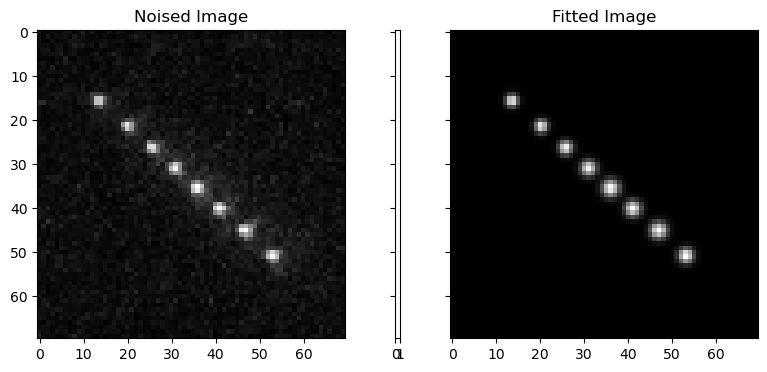

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid
from scipy import optimize

# Assuming the params array is already defined and available in the scope

def GaussianGeneration(params, row, col):
    length = np.shape(params)[0]
    params_num = int((length - 1) // 4)
    gaussian_frame = np.zeros([row, col])
    background = params[-1]
    for m in range(params_num):
        x_pos = params[m * 4]
        y_pos = params[m * 4 + 1]
        sigma = params[m * 4 + 2]
        peak = params[m * 4 + 3]
        for i in range(row):
            for j in range(col):
                gaussian_frame[i, j] += peak * np.exp(-((i - x_pos)**2 + (j - y_pos)**2) / (2 * sigma**2))
    gaussian_frame += background
    return gaussian_frame

# Function to add Poisson noise to the image
def PoissonNoise(image, digit):
    maximum = np.max(image)
    index = int(digit / maximum)
    image_into_digits = (image * index).astype(int)
    noised_image = np.random.poisson(image_into_digits) / index
    return noised_image

# Function to fit the Gaussians to the noisy image
def FindGlobalMinimum(original_image, params, n):
    x_ = np.arange(original_image.shape[0])
    y_ = np.arange(original_image.shape[1])
    X, Y = np.meshgrid(x_, y_)
    
    def residuals(fitting_params, x, y):
        gaussian_image = GaussianGeneration(fitting_params, original_image.shape[0], original_image.shape[1])
        return gaussian_image[x, y] - original_image[x, y]

    def error_func(fitting_params, x, y):
        return np.sum(residuals(fitting_params, x, y)**2)

    fit_result = optimize.basinhopping(error_func, params, niter=n, 
                                      minimizer_kwargs={"method": "bfgs", "args": (X.flatten(), Y.flatten())})
    return np.array(fit_result.x)

point1=np.array([10,5,2,0.3])
point2=np.array([15,10,2,0.3])
point3=np.array([20,15,2,0.3])
point4=np.array([25,20,2,0.3])
point5=np.array([30,25,2,0.3])
point6=np.array([35,30,2,0.3])
point7=np.array([40,35,2,0.3])
point8=np.array([45,40,2,0.3])
background=np.array([0.05])
params=np.concatenate((point1,point2,point3,point4,point5,point6,point7,point8,background),axis = 0)

# Add noise to the generated image
# noised_image = PoissonNoise(image, 32)
zoomed_data_global = contrast_adjusted_data[start_y:end_y, start_x:end_x]
noised_image = zoomed_data_global

# Perform fitting to find the fitted parameters
fitted_params = FindGlobalMinimum(noised_image, params, 8)

# Generate the fitted image using the fitted parameters
fitted_image = GaussianGeneration(fitted_params, zoomed_data_global.shape[0], zoomed_data_global.shape[1])

# Plot the noised, original, and fitted images
fig = plt.figure(figsize=(12, 4))
grid = ImageGrid(fig, 111, nrows_ncols=(1, 3), axes_pad=0.5)

# Noised image
im0 = grid[0].imshow(noised_image, cmap='gray')
grid[0].set_title("Noised Image")
grid.cbar_axes[0].colorbar(im0)

# Fitted image
im2 = grid[2].imshow(fitted_image, cmap='gray')
grid[2].set_title("Fitted Image")
grid.cbar_axes[2].colorbar(im2)

plt.show()